# ProbeA Summary Plot Exploration

This notebook is a sandbox for designing better shareable QC plots. The first target is a channel-selection plot that shows which recorded contacts are represented across shanks, banks, and depth.

The notebook points at an existing completed ProbeA output. Some newer pipeline artifacts may be missing because this output was created before the latest summary/UnitRefine changes.

In [2]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False
})

DATASET_PATH = Path(r"C:\Users\jordan\Desktop\mouse_arena_recordings\jlh602026-06-29_14-31-15\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\spikeinterface_output")
PROBE_JSON = DATASET_PATH / "metadata" / "ProbeA_probeinterface.json"
CHANNEL_QC_CSV = DATASET_PATH / "channel_qc.csv"
QUALITY_METRICS_CSV = DATASET_PATH / "quality_metrics.csv"
SUMMARY_JSON = DATASET_PATH / "summary.json"

assert DATASET_PATH.exists(), DATASET_PATH
assert PROBE_JSON.exists(), PROBE_JSON
DATASET_PATH

WindowsPath('C:/Users/jordan/Desktop/mouse_arena_recordings/jlh602026-06-29_14-31-15/Record Node 101/experiment1/recording1/continuous/Neuropix-PXI-100.ProbeA/spikeinterface_output')

## Load ProbeInterface Geometry

The generated ProbeInterface JSON stores the active/recorded contacts. For NP2-style contact IDs, the parser below also infers `parsed_shank_id`, `electrode_id`, and an approximate `bank` from IDs like `s2e96`.

In [3]:
def load_probe_contacts(probe_json: Path) -> pd.DataFrame:
    data = json.loads(probe_json.read_text(encoding="utf-8"))
    probe = data["probes"][0]
    positions = np.asarray(probe["contact_positions"], dtype=float)
    n_contacts = positions.shape[0]

    contact_ids = probe.get("contact_ids") or [f"contact_{i}" for i in range(n_contacts)]
    shank_ids = probe.get("shank_ids") or [None] * n_contacts
    device_channel_indices = probe.get("device_channel_indices") or list(range(n_contacts))
    annotations = probe.get("contact_annotations", {})
    channel_ids = annotations.get("settings_channel_key") or [f"CH{i}" for i in device_channel_indices]

    rows = []
    for i in range(n_contacts):
        contact_id = str(contact_ids[i])
        match = re.match(r"s(?P<shank>\d+)e(?P<electrode>\d+)", contact_id)
        parsed_shank = int(match.group("shank")) if match else np.nan
        electrode_id = int(match.group("electrode")) if match else np.nan
        bank = int(electrode_id // 384) if np.isfinite(electrode_id) else np.nan
        rows.append({
            "contact_index": i,
            "channel_id": str(channel_ids[i]) if i < len(channel_ids) else f"CH{device_channel_indices[i]}",
            "device_channel_index": int(device_channel_indices[i]),
            "contact_id": contact_id,
            "shank_id": str(shank_ids[i]),
            "parsed_shank_id": parsed_shank,
            "electrode_id": electrode_id,
            "bank": bank,
            "x_um": positions[i, 0],
            "y_um": positions[i, 1],
        })
    contacts = pd.DataFrame(rows)
    contacts["plot_shank"] = contacts["parsed_shank_id"].where(contacts["parsed_shank_id"].notna(), contacts["shank_id"])
    return contacts


def load_channel_qc(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    qc = pd.read_csv(path)
    qc["channel_id"] = qc["channel_id"].astype(str)
    return qc


contacts = load_probe_contacts(PROBE_JSON)
channel_qc = load_channel_qc(CHANNEL_QC_CSV)

if channel_qc.empty:
    contacts["label"] = "good"
    contacts["detected_bad"] = False
    contacts["excluded_from_sorting"] = False
else:
    qc = channel_qc.copy()
    if "label" not in qc.columns and "status" in qc.columns:
        qc["label"] = qc["status"]
    if "label" not in qc.columns:
        qc["label"] = "good"
    if "detected_bad" not in qc.columns:
        qc["detected_bad"] = qc["label"].astype(str).str.lower().ne("good")
    if "excluded_from_sorting" not in qc.columns:
        qc["excluded_from_sorting"] = False

    merge_cols = ["label", "detected_bad", "excluded_from_sorting"]
    if "channel_id" in qc.columns:
        qc["channel_id"] = qc["channel_id"].astype(str)
        contacts = contacts.merge(qc[["channel_id", *merge_cols]], on="channel_id", how="left")
    elif "channel_index" in qc.columns:
        contacts = contacts.merge(qc[["channel_index", *merge_cols]], left_on="contact_index", right_on="channel_index", how="left")
    else:
        contacts["label"] = "good"
        contacts["detected_bad"] = False
        contacts["excluded_from_sorting"] = False

if "label" not in contacts.columns:
    contacts["label"] = "good"
if "detected_bad" not in contacts.columns:
    contacts["detected_bad"] = False
if "excluded_from_sorting" not in contacts.columns:
    contacts["excluded_from_sorting"] = False
contacts["label"] = contacts["label"].fillna("good")
contacts["detected_bad"] = contacts["detected_bad"].fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})
contacts["excluded_from_sorting"] = contacts["excluded_from_sorting"].fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})

display(contacts.head())
display(contacts.groupby(["plot_shank", "bank"], dropna=False).size().rename("active_contacts").reset_index())

,contact_index,channel_id,device_channel_index,contact_id,shank_id,parsed_shank_id,electrode_id,bank,x_um,y_um,plot_shank,label,detected_bad,excluded_from_sorting
0,0,CH0,0,s2e96,2,2,96,0,500.0,720.0,2,noise,True,False
1,1,CH1,1,s2e97,2,2,97,0,532.0,720.0,2,noise,True,False
2,2,CH2,2,s2e98,2,2,98,0,500.0,735.0,2,noise,True,False
3,3,CH3,3,s2e99,2,2,99,0,532.0,735.0,2,noise,True,False
4,4,CH4,4,s2e100,2,2,100,0,500.0,750.0,2,noise,True,False


,plot_shank,bank,active_contacts
0,0,0,96
1,1,0,96
2,2,0,96
3,3,0,96


## Select Channels Across Shank, Bank, And Depth

This deterministic selection chooses a small set of channels per shank/bank group, spread from low to high depth. These are candidates for pre/post CAR trace examples or compact raw-trace panels.

In [4]:
def select_channels_across_probe(contacts: pd.DataFrame, per_group: int = 2, max_channels: int = 32) -> pd.DataFrame:
    group_cols = [col for col in ["plot_shank", "bank"] if contacts[col].nunique(dropna=False) > 1]
    if not group_cols:
        group_cols = ["plot_shank"]

    selected_indices = []
    for _, group in contacts.sort_values("y_um").groupby(group_cols, dropna=False):
        if group.empty:
            continue
        n = min(per_group, len(group))
        positions = np.linspace(0, len(group) - 1, n, dtype=int)
        selected_indices.extend(group.iloc[positions].index.tolist())

    selected = contacts.loc[selected_indices].drop_duplicates("channel_id")
    if len(selected) > max_channels:
        selected = selected.sort_values(["plot_shank", "bank", "y_um"]).iloc[np.linspace(0, len(selected) - 1, max_channels, dtype=int)]
    return selected.sort_values(["plot_shank", "bank", "y_um", "x_um"])


selected_contacts = select_channels_across_probe(contacts, per_group=2, max_channels=32)
display(selected_contacts[["channel_id", "contact_id", "plot_shank", "bank", "electrode_id", "x_um", "y_um", "label", "detected_bad"]])

,channel_id,contact_id,plot_shank,bank,electrode_id,x_um,y_um,label,detected_bad
192,CH192,s0e96,0,0,96,0.0,720.0,good,False
334,CH334,s0e190,0,0,190,0.0,1425.0,good,False
241,CH241,s1e97,1,0,97,282.0,720.0,good,False
383,CH383,s1e191,1,0,191,282.0,1425.0,good,False
1,CH1,s2e97,2,0,97,532.0,720.0,noise,True
143,CH143,s2e191,2,0,191,532.0,1425.0,noise,True
48,CH48,s3e96,3,0,96,750.0,720.0,good,False
190,CH190,s3e190,3,0,190,750.0,1425.0,good,False


## Plot 1: Selected Channels On Probe Geometry

Gray points are all recorded contacts in the generated ProbeInterface map. Larger colored points are the selected example channels. Red outlines mark channels flagged by bad-channel detection.

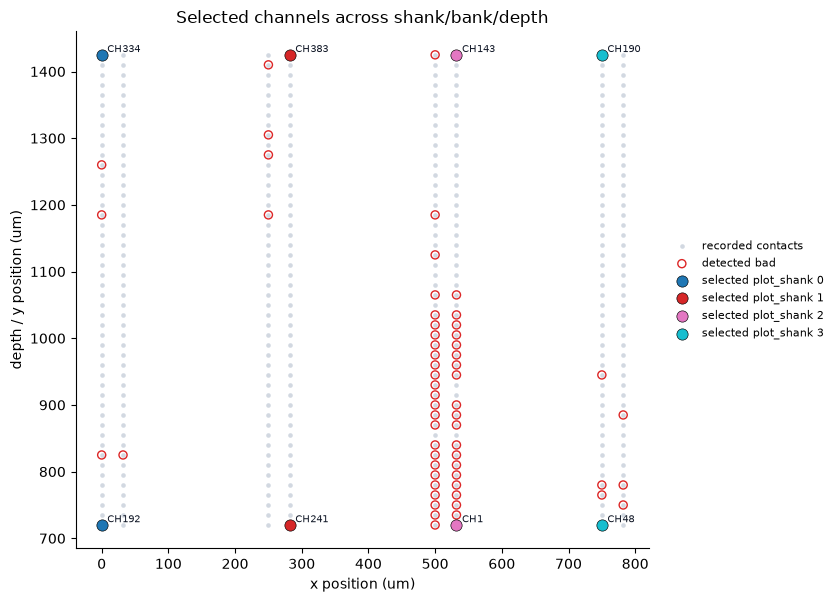

In [5]:
def plot_selected_channels(contacts: pd.DataFrame, selected: pd.DataFrame, *, title: str = "Selected channels across shank/bank/depth"):
    fig, ax = plt.subplots(figsize=(8.5, 9.5))
    ax.scatter(contacts["x_um"], contacts["y_um"], s=11, color="#94a3b8", alpha=0.42, linewidth=0, label="recorded contacts")

    bad = contacts[contacts["detected_bad"]]
    if not bad.empty:
        ax.scatter(bad["x_um"], bad["y_um"], s=34, facecolors="none", edgecolors="#dc2626", linewidth=1.0, label="detected bad")

    color_key = "bank" if selected["bank"].nunique(dropna=False) > 1 else "plot_shank"
    categories = selected[color_key].astype(str).fillna("unknown")
    palette = dict(zip(sorted(categories.unique()), plt.cm.tab10(np.linspace(0, 1, max(1, categories.nunique())))))
    for category, group in selected.groupby(categories):
        ax.scatter(group["x_um"], group["y_um"], s=66, color=palette[str(category)], edgecolor="black", linewidth=0.45, label=f"selected {color_key} {category}")
        for _, row in group.iterrows():
            ax.annotate(row["channel_id"], (row["x_um"], row["y_um"]), xytext=(4, 2), textcoords="offset points", fontsize=7, color="#111827")

    ax.set_title(title)
    ax.set_xlabel("x position (um)")
    ax.set_ylabel("depth / y position (um)")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_selected_channels(contacts, selected_contacts)
plt.show()

## Plot 2: Full NP2.0 Contact Map With Recorded Contacts

All theoretical NP2.0 contacts are shown as small gray dots. The contacts actually recorded in this Open Ephys stream are shown in blue. The left y-axis is physical depth; the right y-axis labels nearby recorded channel numbers.

C:\Users\jordan\AppData\Local\Temp\ipykernel_39240\3847503837.py:59: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  theoretical["detected_bad"] = theoretical["detected_bad"].fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})


,max_abs_x_error_um,max_abs_y_error_um,recorded_contacts_checked
0,0.0,0.0,384


,plot_shank,bank,theoretical_contacts,recorded_contacts
0,0,0,384,96
1,0,1,384,0
2,0,2,384,0
3,0,3,128,0
4,1,0,384,96
5,1,1,384,0
6,1,2,384,0
7,1,3,128,0
8,2,0,384,96
9,2,1,384,0


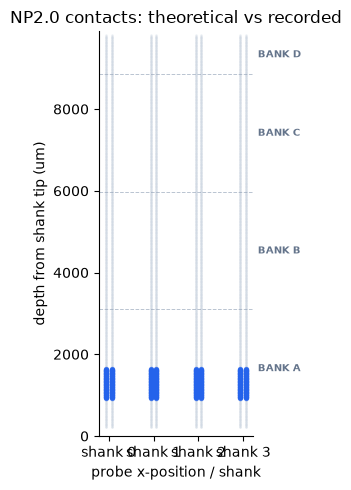

In [16]:
def _median_positive_diff(values, fallback):
    unique = np.sort(pd.Series(values).dropna().astype(float).unique())
    diffs = np.diff(unique)
    diffs = diffs[diffs > 0]
    return float(np.median(diffs)) if diffs.size else float(fallback)


def _load_shank_tip_y(probe_json: Path) -> dict[int, float]:
    data = json.loads(probe_json.read_text(encoding="utf-8"))
    probe = data["probes"][0]
    tips = probe.get("annotations", {}).get("shank_tips", [])
    return {int(index): float(tip[1]) for index, tip in enumerate(tips) if len(tip) >= 2}


def build_theoretical_np2_contacts(recorded_contacts: pd.DataFrame, contacts_per_shank: int = 1280) -> pd.DataFrame:
    recorded = recorded_contacts.copy()
    recorded["parsed_shank_id"] = pd.to_numeric(recorded["parsed_shank_id"], errors="coerce")
    recorded["electrode_id"] = pd.to_numeric(recorded["electrode_id"], errors="coerce")
    recorded = recorded.dropna(subset=["parsed_shank_id", "electrode_id", "x_um", "y_um"])

    x_pitch = _median_positive_diff(recorded.groupby(["parsed_shank_id", "y_um"])["x_um"].agg(lambda x: np.ptp(np.sort(x.unique()))), 32.0)
    y_pitch = _median_positive_diff(recorded["y_um"], 15.0)
    y_offset = float(np.median(recorded["y_um"].to_numpy() - (recorded["electrode_id"].astype(int).to_numpy() // 2) * y_pitch))
    tip_y_by_shank = _load_shank_tip_y(PROBE_JSON)

    shank_bases = {}
    for shank, group in recorded.groupby("parsed_shank_id"):
        column_offsets = (group["electrode_id"].astype(int) % 2) * x_pitch
        shank_bases[int(shank)] = float(np.median(group["x_um"].to_numpy() - column_offsets.to_numpy()))
    if not shank_bases:
        shank_bases = {shank: shank * 250.0 for shank in range(4)}
    shank_spacing = _median_positive_diff(list(shank_bases.values()), 250.0)
    for shank in range(4):
        shank_bases.setdefault(shank, min(shank_bases.values()) + shank * shank_spacing)

    rows = []
    for shank in range(4):
        base_x = shank_bases[shank]
        for electrode_id in range(contacts_per_shank):
            rows.append({
                "contact_id": f"s{shank}e{electrode_id}",
                "plot_shank": shank,
                "electrode_id": electrode_id,
                "bank": electrode_id // 384,
                "x_um": base_x + (electrode_id % 2) * x_pitch,
                "y_um": y_offset + (electrode_id // 2) * y_pitch,
            })
    theoretical = pd.DataFrame(rows)
    theoretical["tip_y_um"] = theoretical["plot_shank"].map(tip_y_by_shank).fillna(theoretical["y_um"].min() - 217.0)
    theoretical["depth_from_tip_um"] = theoretical["y_um"] - theoretical["tip_y_um"]
    recorded_columns = ["contact_id", "channel_id", "label", "detected_bad", "excluded_from_sorting"]
    recorded_lookup = recorded_contacts[[c for c in recorded_columns if c in recorded_contacts.columns]].copy()
    theoretical = theoretical.merge(recorded_lookup, on="contact_id", how="left")
    theoretical["was_recorded"] = theoretical["channel_id"].notna()
    if "detected_bad" not in theoretical.columns:
        theoretical["detected_bad"] = False
    if "label" not in theoretical.columns:
        theoretical["label"] = "not recorded"
    theoretical["detected_bad"] = theoretical["detected_bad"].fillna(False).astype(str).str.lower().isin({"true", "1", "yes"})
    theoretical["label"] = theoretical["label"].fillna("not recorded")
    return theoretical


theoretical_contacts = build_theoretical_np2_contacts(contacts)
alignment_check = theoretical_contacts.merge(
    contacts[["contact_id", "x_um", "y_um"]],
    on="contact_id",
    how="inner",
    suffixes=("_theoretical", "_recorded"),
)
display(pd.DataFrame([{
    "max_abs_x_error_um": (alignment_check["x_um_theoretical"] - alignment_check["x_um_recorded"]).abs().max(),
    "max_abs_y_error_um": (alignment_check["y_um_theoretical"] - alignment_check["y_um_recorded"]).abs().max(),
    "recorded_contacts_checked": len(alignment_check),
}]))

coverage = theoretical_contacts.groupby(["plot_shank", "bank"], dropna=False).agg(
    theoretical_contacts=("contact_id", "size"),
    recorded_contacts=("was_recorded", "sum"),
).reset_index()
coverage["recorded_contacts"] = coverage["recorded_contacts"].astype(int)

display(coverage)

fig, ax = plt.subplots(figsize=(3, 5))
all_contacts = theoretical_contacts[~theoretical_contacts["was_recorded"]]
recorded = theoretical_contacts[theoretical_contacts["was_recorded"]]

ax.scatter(all_contacts["x_um"], all_contacts["depth_from_tip_um"], s=3, color="#cbd5e1", alpha=0.38, linewidth=0)
ax.scatter(recorded["x_um"], recorded["depth_from_tip_um"], s=15, color="#2563eb", alpha=0.82, linewidth=0)

bank_boundary_depths = theoretical_contacts[
    theoretical_contacts["electrode_id"].isin([384, 768, 1152])
].groupby("electrode_id")["depth_from_tip_um"].median().sort_index()
for depth in bank_boundary_depths:
    ax.axhline(depth, color="#94a3b8", linewidth=0.7, linestyle="--", alpha=0.65)

bank_labels = {0: "BANK A", 1: "BANK B", 2: "BANK C", 3: "BANK D"}
bank_centers = theoretical_contacts.groupby("bank")["depth_from_tip_um"].median().sort_index()
for bank, depth in bank_centers.items():
    ax.text(
        1.03,
        depth,
        bank_labels.get(int(bank), f"BANK {int(bank)}"),
        transform=ax.get_yaxis_transform(),
        ha="left",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="#64748b",
        clip_on=False,
    )

shank_centers = theoretical_contacts.groupby("plot_shank")["x_um"].mean().sort_index()
ax.set_xticks(shank_centers.to_numpy())
ax.set_xticklabels([f"shank {int(shank)}" for shank in shank_centers.index])
ax.set_xlabel("probe x-position / shank")
ax.set_ylim(0, theoretical_contacts["depth_from_tip_um"].max() + 100)
ax.set_ylabel("depth from shank tip (um)")
ax.set_title("NP2.0 contacts: theoretical vs recorded")

fig.tight_layout()
plt.show()

## Starter Panel: Existing Quality Metrics

A compact metric panel like this can become part of the final shareable summary sheet.

,count,mean,std,min,25%,50%,75%,max
firing_rate,329.0,5.865718,10.907981,0.013597,0.295931,1.089346,6.118171,67.713785
snr,329.0,6.642530,1.449850,5.274163,6.002083,6.191045,6.467505,13.623283
presence_ratio,329.0,0.957150,0.120910,0.365854,1.000000,1.000000,1.000000,1.000000
amplitude_cutoff,269.0,0.000077,0.000716,0.000000,0.000000,0.000000,0.000000,0.009768
amplitude_median,329.0,-644.224256,187.061676,-1379.234985,-655.979980,-634.529968,-610.154968,537.224976
isi_violations_ratio,329.0,6.035708,18.438871,0.000000,0.029384,0.566228,3.692441,210.460287
rp_contamination,329.0,0.424411,0.462194,0.000000,0.001111,0.137516,1.000000,1.000000


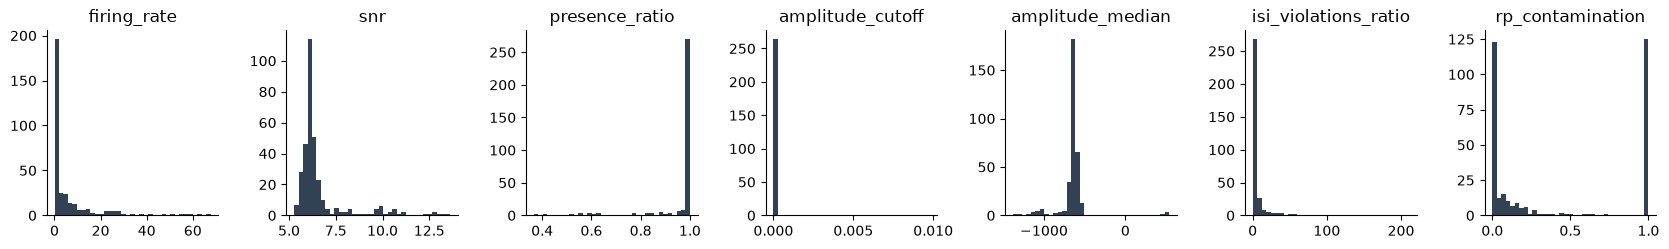

In [7]:
def read_metrics(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    metrics = pd.read_csv(path)
    if metrics.columns[0].startswith("Unnamed"):
        metrics = metrics.set_index(metrics.columns[0])
    return metrics


metrics = read_metrics(QUALITY_METRICS_CSV)
metric_cols = [c for c in ["firing_rate", "snr", "presence_ratio", "amplitude_cutoff", "amplitude_median", "isi_violations_ratio", "rp_contamination"] if c in metrics]
display(metrics[metric_cols].describe().T if metric_cols else "No quality metrics found")

if metric_cols:
    fig, axes = plt.subplots(1, len(metric_cols), figsize=(2.4 * len(metric_cols), 2.6))
    if len(metric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, metric_cols):
        values = pd.to_numeric(metrics[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(values, bins=35, color="#334155")
        ax.set_title(col)
    fig.tight_layout()
    plt.show()

## Save Candidate Figure

Uncomment this once a candidate plot looks worth keeping.

In [ ]:
# candidate_dir = DATASET_PATH / "report" / "figures" / "exploration"
# candidate_dir.mkdir(parents=True, exist_ok=True)
# fig, ax = plot_selected_channels(contacts, selected_contacts)
# fig.savefig(candidate_dir / "selected_channels_by_shank_bank.png", bbox_inches="tight")